In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [16]:
# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 500

data = {
    'Customer_ID': [f'CUST_{i:03d}' for i in range(1, n_samples + 1)],
    'Gender': np.random.choice(['Male', 'Female'], size=n_samples, p=[0.48, 0.52]),
    'Subscription_Type': np.random.choice(['Basic', 'Standard', 'Premium'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'Payment_Method': np.random.choice(['Credit Card', 'Bank Transfer', 'Electronic Wallet'], size=n_samples, p=[0.4, 0.25, 0.35]),
    'Contract_Length': np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], size=n_samples, p=[0.6, 0.2, 0.2]),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], size=n_samples),
    'Satisfied': np.random.choice(['Yes', 'No'], size=n_samples, p=[0.7, 0.3]),
    'Status': np.random.choice(['Active', 'Churned'], size=n_samples, p=[0.8, 0.2]),
    'Monthly_Charges': np.random.uniform(30.0, 120.0, size=n_samples).round(2),
    'Total_Data_Usage_GB': np.random.uniform(10.0, 500.0, size=n_samples).round(1),
}

# Create DataFrame
df = pd.DataFrame(data)

# Injecting a realistic pattern: Month-to-month contracts are way more likely to churn
df.loc[df['Contract_Length'] == 'Month-to-Month', 'Status'] = np.random.choice(
    ['Active', 'Churned'], size=len(df[df['Contract_Length'] == 'Month-to-Month']), p=[0.65, 0.35]
)

# Display first few rows
(df.head())

,Customer_ID,Gender,Subscription_Type,Payment_Method,Contract_Length,Region,Satisfied,Status,Monthly_Charges,Total_Data_Usage_GB
0,CUST_001,Male,Standard,Credit Card,Month-to-Month,West,Yes,Active,77.93,448.8
1,CUST_002,Female,Standard,Bank Transfer,Month-to-Month,East,No,Active,40.39,455.5
2,CUST_003,Female,Basic,Electronic Wallet,Month-to-Month,East,Yes,Active,84.51,163.8
3,CUST_004,Female,Premium,Electronic Wallet,Month-to-Month,East,No,Active,40.55,348.6
4,CUST_005,Male,Standard,Electronic Wallet,Month-to-Month,West,No,Active,60.35,143.1


In [17]:
pd.crosstab(df["Subscription_Type"], df["Region"])

Region,East,North,South,West
Subscription_Type,,,,
Basic,68,66,62,66
Premium,19,19,31,24
Standard,37,33,27,48


In [18]:
df.pivot_table(
    index="Subscription_Type",
    values="Monthly_Charges",
    aggfunc="mean",
    fill_value=0
)

# Put categorical data in Index and numeric data in Values

,Monthly_Charges
Subscription_Type,
Basic,75.000191
Premium,74.120323
Standard,74.958828


<Axes: title={'center': 'Monthly_Charges'}, xlabel='Subscription_Type'>

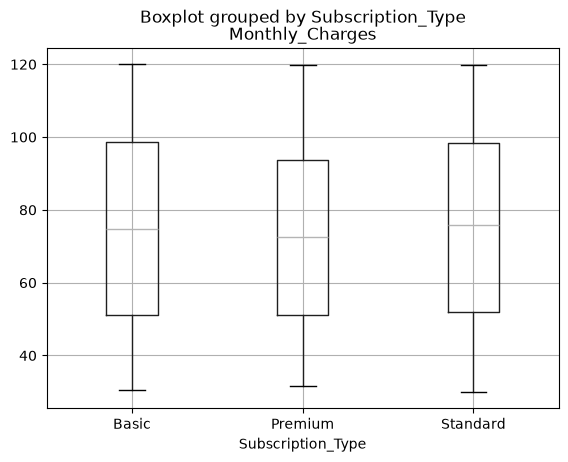

In [19]:
df.boxplot(column = "Monthly_Charges", by = "Subscription_Type")

# Violin Plot

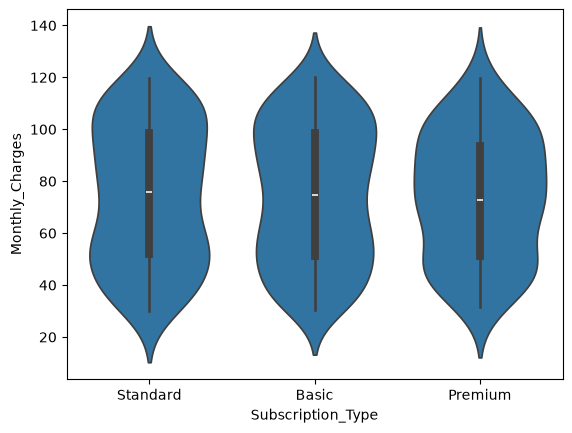

In [20]:
sns.violinplot(x = "Subscription_Type", y = "Monthly_Charges", data = df)
plt.show()

# Inside there is a box Plot

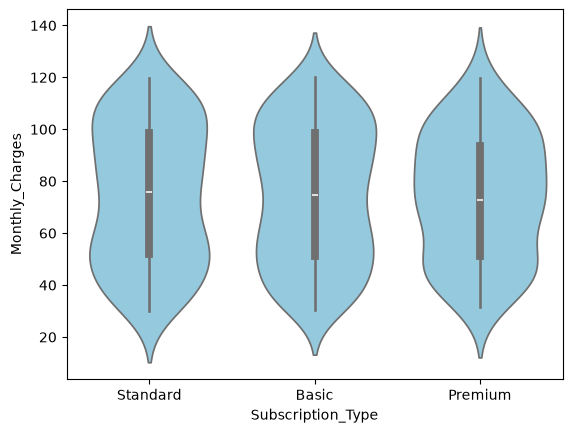

In [21]:
sns.violinplot(x = "Subscription_Type", y = "Monthly_Charges", data = df, color="skyblue")
plt.show()

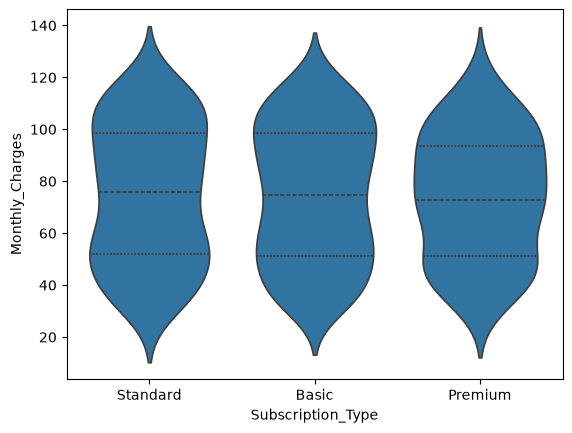

In [22]:
sns.violinplot(x = "Subscription_Type", y = "Monthly_Charges", data = df, inner = "quartile")
plt.show()

# Now inside is labeled as Quantilesp

# KDE Plot (Kernal Density Estimation)

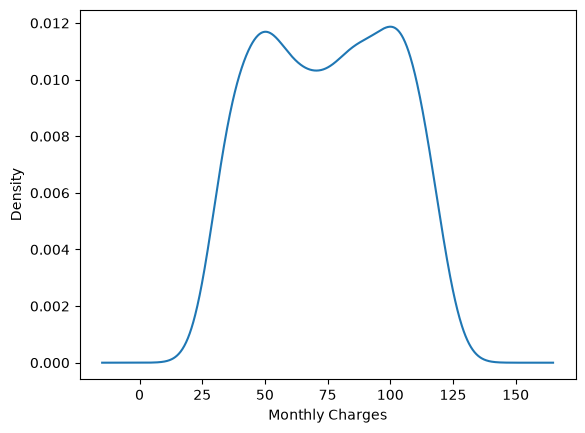

In [23]:
df["Monthly_Charges"].plot.kde()
plt.xlabel("Monthly Charges")

plt.show()

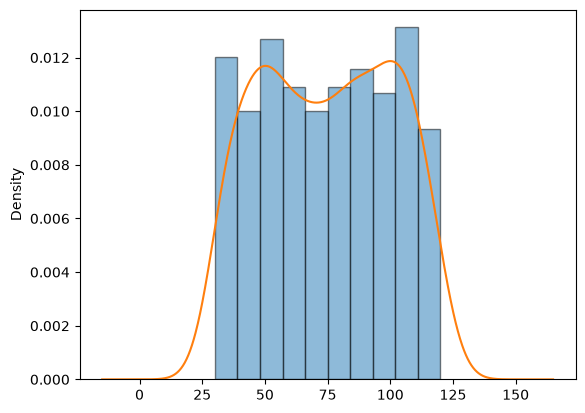

In [24]:
# Histogram + KDE 

df["Monthly_Charges"].plot.hist(
    bins = 10,
    density = True,
    alpha = 0.5,
    edgecolor = "black"
)

df["Monthly_Charges"].plot.kde()

plt.show()

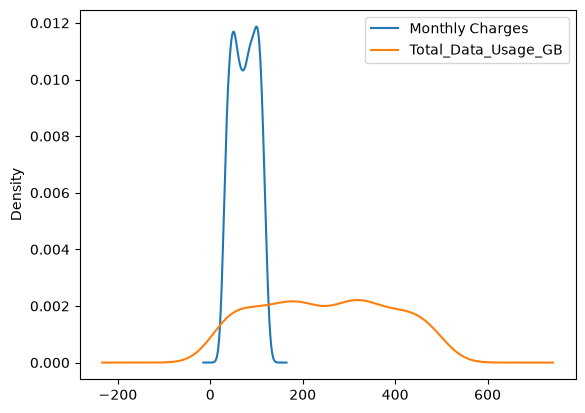

In [25]:
# Multiple Variables

df["Monthly_Charges"].plot.kde(label = "Monthly Charges")
df["Total_Data_Usage_GB"].plot.kde(label = "Total_Data_Usage_GB")

plt.legend()
plt.show()


# 📚 Revision Summary – Exploring Two or More Variables

---

# 1. Contingency Table (Cross Tabulation)

A **contingency table** summarizes the relationship between **two categorical variables** by counting the number of observations in each category combination.

### Example

| Grade | Paid | Late |
|-------|------|------|
| A | 20 | 2 |
| B | 15 | 8 |

### Uses

- Compare two categorical variables.
- Find patterns and relationships.
- Common in surveys, business analytics, and classification problems.

---

# 2. Row Percentage

Raw counts can be misleading when category sizes differ.

Row percentages normalize each row by its total, allowing fair comparisons.

### The KDE Formula

The mathematical formula for Kernel Density Estimation is:

$$
\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)
$$

---

### Meaning of Symbols

$$
\begin{aligned}
\hat{f}(x) & : \text{Estimated probability density at point } x \\[6pt]
n & : \text{Total number of data points} \\[6pt]
h & : \text{Bandwidth (controls the smoothness of the density curve)} \\[6pt]
K(\cdot) & : \text{Kernel function (commonly the Gaussian kernel)} \\[6pt]
x_i & : \text{The } i^{\text{th}} \text{ observed data point} \\[6pt]
x & : \text{The specific point where the density is being estimated}
\end{aligned}
$$
---

# 3. Pivot Table

A **pivot table** is a flexible summary table that groups data and performs aggregation.

Common aggregations:

- Count
- Sum
- Mean
- Median
- Minimum
- Maximum

Used for quickly summarizing large datasets.

---

# 4. Categorical vs Numeric Variables

When comparing a **numeric variable** across different **categories**, visualizations are preferred over simple summary statistics.

Example:

- Airline → Categorical
- Delay Time → Numeric

Useful plots:

- Boxplot
- Violin Plot

---

# 5. Boxplot

A **boxplot** summarizes the distribution of numerical data using the **Five-Number Summary**.

### Five-Number Summary

- Minimum
- First Quartile (Q1)
- Median (Q2)
- Third Quartile (Q3)
- Maximum

### Shows

- Center (Median)
- Spread (IQR)
- Skewness
- Outliers

### Advantages

- Compact summary
- Easy comparison between groups
- Clearly identifies outliers

### Limitation

Does **not** show the detailed shape of the distribution.

---

# 6. Violin Plot

A **violin plot** combines a boxplot with a **Kernel Density Estimation (KDE)** curve.

### Shows

- Distribution shape
- Density of observations
- Quartiles (optional)

### Interpretation

- Wider regions → Higher data density
- Narrow regions → Lower data density

### Advantages

- Reveals clusters and distribution shape.
- More informative than a boxplot.

### Limitation

Outliers are less obvious than in a boxplot.

---

# 7. Kernel Density Estimation (KDE)

KDE is a **smoothed estimate of a probability density function**.

It estimates where observations are concentrated without dividing the data into bins like a histogram.

\[
\hat{f}(x)=\frac{1}{nh}\sum_{i=1}^{n}K\left(\frac{x-x_i}{h}\right)
\]

### Interpretation

- High peak → Many observations
- Low peak → Few observations
- Wide curve → Greater variability
- Narrow curve → Less variability

### Advantages

- Smooth representation of the distribution.
- Easier to compare multiple distributions.
- No dependence on histogram bin size.

### Best Used For

- Continuous numerical variables.
- Comparing distributions.
- Identifying clusters and spread.

### Avoid Using For

- Categorical variables
- Very small datasets

---

# Comparison

| Plot | Best For | Shows Outliers | Shows Distribution Shape |
|------|-----------|---------------|--------------------------|
| Histogram | Frequency | ❌ | Partial |
| Boxplot | Summary | ✅ | ❌ |
| Violin Plot | Summary + Shape | Partial | ✅ |
| KDE Plot | Distribution Shape | ❌ | ✅ |

---

# Key Takeaways

- **Contingency Table** → Relationship between two categorical variables.
- **Pivot Table** → Flexible grouped summary of data.
- **Boxplot** → Five-number summary + outliers.
- **Violin Plot** → Boxplot + KDE.
- **KDE** → Smooth estimate of data density.
- Use **Boxplots** for concise summaries and **Violin/KDE plots** when the distribution shape matters.